In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

In [4]:
ds_hr_solar= xr.open_dataset("/home/dtaneja/analysis-dishika/notebooks/HRDPS_2007_solar.nc")
solar = ds_hr_solar["solar"]
X_hr_solar = solar.values.reshape(2904, 266 * 256)
pca_hr_solar = PCA(n_components=2)
PCs_hr_solar = pca_hr_solar.fit_transform(X_hr_solar)
PCs_hr_solar.shape

(2904, 2)

In [5]:
print("Eigenvectors (Principal Components):")
print(pca_hr_solar.components_)
print("PC scores:")
print(PCs_hr_solar)
print("Explained Variance Ratio:")
print(pca_hr_solar.explained_variance_ratio_)
print("Total Variance Explained by the 2 Principal Components:")
print(pca_hr_solar.explained_variance_ratio_.sum())

Eigenvectors (Principal Components):
[[ 0.0040077   0.00400669  0.0040127  ...  0.00362554  0.00364674
   0.00364445]
 [ 0.00327532  0.00326706  0.00327573 ... -0.00327957 -0.00335935
  -0.00342428]]
PC scores:
[[-38055.89       1323.6903  ]
 [-40581.75         70.72275 ]
 [-40581.75         70.706764]
 ...
 [-39081.4        -128.14655 ]
 [  6269.491       643.1455  ]
 [ 16939.768     -3665.5723  ]]
Explained Variance Ratio:
[0.9017883  0.02422545]
Total Variance Explained by the 2 Principal Components:
0.92601377


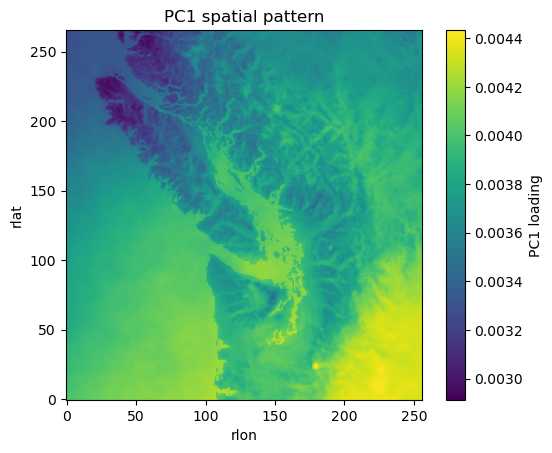

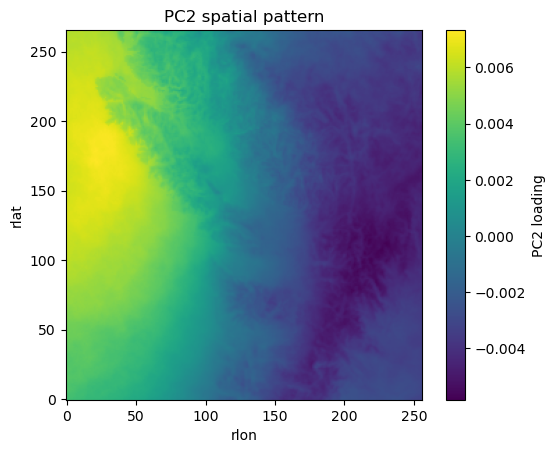

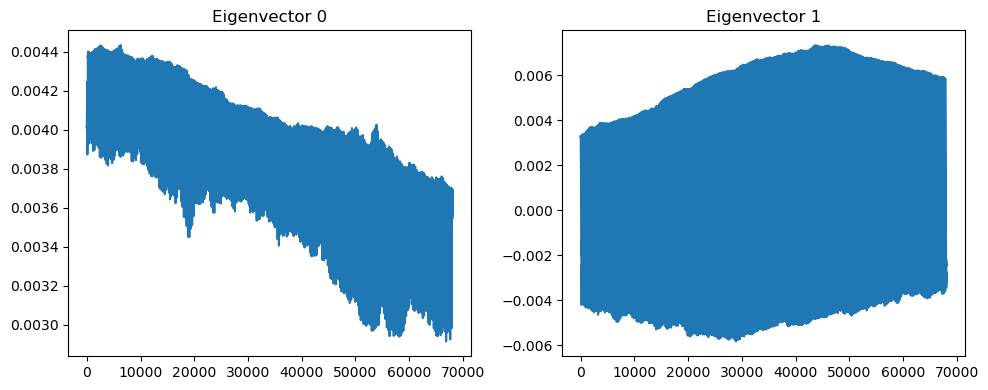

In [6]:
# Visualize the spatial patterns of the first two principal components
PC1_map_hr_solar = pca_hr_solar.components_[0].reshape(266, 256)
plt.imshow(PC1_map_hr_solar, origin="lower")
plt.colorbar(label="PC1 loading")
plt.title("PC1 spatial pattern")
plt.xlabel("rlon")
plt.ylabel("rlat")
plt.show()

PC2_map_hr_solar = pca_hr_solar.components_[1].reshape(266, 256)
plt.imshow(PC2_map_hr_solar, origin="lower")
plt.colorbar(label="PC2 loading")
plt.title("PC2 spatial pattern")
plt.xlabel("rlon")
plt.ylabel("rlat")
plt.show()

# Spatial eigenvectors (loadings) for the first two principal components as 1D line plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(pca_hr_solar.components_[0])
axes[0].set_title("Eigenvector 0")
axes[1].plot(pca_hr_solar.components_[1])
axes[1].set_title("Eigenvector 1")
plt.tight_layout()
plt.show()

In [7]:
hrdps = sorted(glob.glob('/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m??d??.nc'))
combined = []
for file in hrdps:
    ds = xr.open_dataset(file)
    pressure_data = ds["atmpres"]
    combined.append(pressure_data.resample(time_counter="3h",label="left",closed="left",origin="start_day").mean())

xr.concat(combined, dim="time_counter").to_dataset(name="pressure").to_netcdf("/home/dtaneja/analysis-dishika/notebooks/HRDPS_2007_pressure.nc")

In [8]:
ds_hr_pressure= xr.open_dataset("/home/dtaneja/analysis-dishika/notebooks/HRDPS_2007_pressure.nc")
pressure = ds_hr_pressure["pressure"]
X_hr_pressure = pressure.values.reshape(2904, 266 * 256)
pca_hr_pressure = PCA(n_components=2)
PCs_hr_pressure = pca_hr_pressure.fit_transform(X_hr_pressure)

In [9]:
print("Eigenvectors (Principal Components):")
print(pca_hr_pressure.components_)
print("PC scores:")
print(PCs_hr_pressure)
print("Explained Variance Ratio:")
print(pca_hr_pressure.explained_variance_ratio_)
print("Total Variance Explained by the 2 Principal Components:")
print(pca_hr_pressure.explained_variance_ratio_.sum())

Eigenvectors (Principal Components):
[[ 0.00349927  0.00349781  0.00349625 ...  0.00407884  0.00402725
   0.00397195]
 [-0.0047651  -0.00474233 -0.00472007 ...  0.00606297  0.00571047
   0.00536972]]
PC scores:
[[-399449.2    -37408.58 ]
 [-364888.16   -27151.967]
 [-341864.9    -19617.996]
 ...
 [ 453217.16    40387.26 ]
 [ 469530.62    47490.805]
 [ 429453.2     63780.25 ]]
Explained Variance Ratio:
[0.88092774 0.06231843]
Total Variance Explained by the 2 Principal Components:
0.9432462


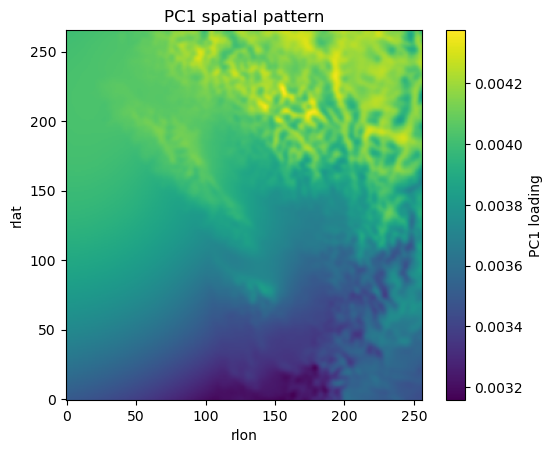

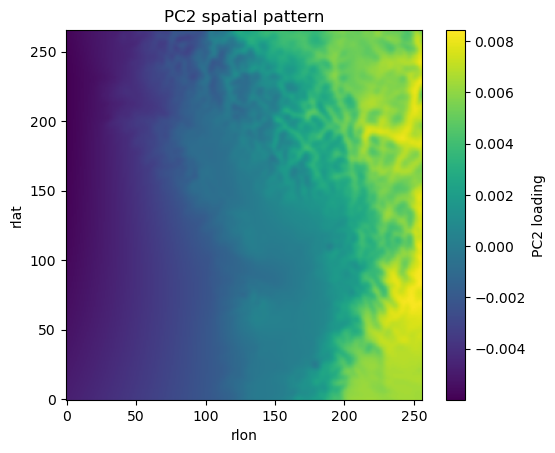

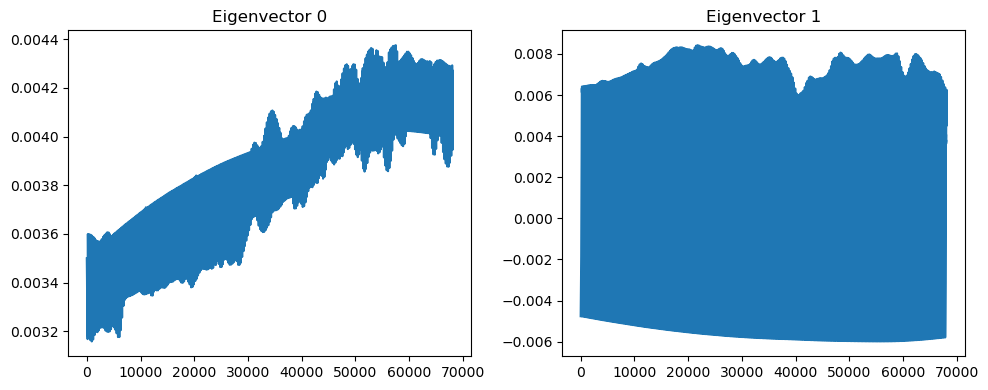

In [10]:
# Visualize the spatial patterns of the first two principal components
PC1_map_hr_pressure = pca_hr_pressure.components_[0].reshape(266, 256)
plt.imshow(PC1_map_hr_pressure, origin="lower")
plt.colorbar(label="PC1 loading")
plt.title("PC1 spatial pattern")
plt.xlabel("rlon")
plt.ylabel("rlat")
plt.show()

PC2_map_hr_pressure = pca_hr_pressure.components_[1].reshape(266, 256)
plt.imshow(PC2_map_hr_pressure, origin="lower")
plt.colorbar(label="PC2 loading")
plt.title("PC2 spatial pattern")
plt.xlabel("rlon")
plt.ylabel("rlat")
plt.show()

# Spatial eigenvectors (loadings) for the first two principal components as 1D line plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(pca_hr_pressure.components_[0])
axes[0].set_title("Eigenvector 0")
axes[1].plot(pca_hr_pressure.components_[1])
axes[1].set_title("Eigenvector 1")
plt.tight_layout()
plt.show()

In [11]:
files = sorted(glob.glob('/results/forcing/CanRCM5/*2007*.nc'))
for file in files:
    if "psl" in xr.open_dataset(file).data_vars: 
        ds = xr.open_dataset(file) 
        break

ds_2007 = ds.sel(time=slice("2007-01-03", "2007-12-31")) #Select data from January 2007

ds0 = xr.open_dataset(hrdps[0])

lat_hr = ds0["nav_lat"]
lon_hr = ds0["nav_lon"]

ds_new = xr.open_dataset("/home/dtaneja/analysis-dishika/notebooks/HRDPS_2007_pressure.nc")

ds_new = ds_new.assign_coords(
    nav_lat=(("y", "x"), lat_hr.values),
    nav_lon=(("y", "x"), lon_hr.values)
)

ds_new.to_netcdf("/home/dtaneja/analysis-dishika/notebooks/HRDPS_2007_pressure_with_latlon.nc")


In [12]:
corners = { "bottom_left": (float(lat_hr.isel(y=0, x=0)),float(lon_hr.isel(y=0, x=0))),
           "bottom_right": (float(lat_hr.isel(y=0, x=-1)),float(lon_hr.isel(y=0, x=-1))),
           "top_left": (float(lat_hr.isel(y=-1, x=0)),float(lon_hr.isel(y=-1, x=0))),
           "top_right": (float(lat_hr.isel(y=-1, x=-1)),float(lon_hr.isel(y=-1, x=-1)))}

for name, (lat, lon) in corners.items():
    print("name:", name)
    print("lat:", lat)
    print("lon:", lon)

name: bottom_left
lat: 45.61257553100586
lon: 232.6595001220703
name: bottom_right
lat: 46.535892486572266
lon: 240.79672241210938
name: top_left
lat: 51.41788864135742
lon: 230.60208129882812
name: top_right
lat: 52.4603157043457
lon: 239.75860595703125


In [13]:
hr_lats = []
hr_lons = []
for coord in corners.values():
    hr_lats.append(coord[0])
    hr_lons.append(coord[1])

lat_min = min(hr_lats)
lat_max = max(hr_lats)
lon_min = min(hr_lons)
lon_max = max(hr_lons)

print(lat_min, lat_max)
print(lon_min, lon_max)

45.61257553100586 52.4603157043457
230.60208129882812 240.79672241210938


In [14]:
lat_lr = ds_2007["lat"]
lon_lr = ds_2007["lon"]
# Converts longitudes from 0-360 to -180 to 180
lon_lr = ((lon_lr + 180) % 360) - 180
# Converts longitudes from 0-360 to -180 to 180
lon_min = ((lon_min + 180) % 360) - 180
lon_max = ((lon_max + 180) % 360) - 180
# Create a mask to identify which CanRCM5 grid cells fall within the HRDPS region
mask_lr = (
    (lat_lr >= lat_min) & (lat_lr <= lat_max) &
    (lon_lr >= lon_min) & (lon_lr <= lon_max)
)

print("Number of CanRCM5 cells in HRDPS region:", int(mask_lr.sum()))


Number of CanRCM5 cells in HRDPS region: 947


In [15]:
i_idx, j_idx = np.where(mask_lr.values) # Finds array indices where mask_lr is True

i_min, i_max = i_idx.min(), i_idx.max()
j_min, j_max = j_idx.min(), j_idx.max()

print(i_min, i_max, j_min, j_max) # These indices can be used to subset the CanRCM5 data to the HRDPS region for further analysis

162 200 79 117


In [16]:
ds_2007_cut = ds_2007.isel(rlat=slice(i_min, i_max + 1),rlon=slice(j_min, j_max + 1))

print(ds_2007_cut)
print(ds_2007_cut["psl"].shape)

<xarray.Dataset> Size: 18MB
Dimensions:       (time: 2904, bnds: 2, rlat: 39, rlon: 39)
Coordinates:
  * time          (time) object 23kB 2007-01-03 00:00:00 ... 2007-12-31 21:00:00
  * rlat          (rlat) float64 312B 0.53 0.75 0.97 1.19 ... 8.45 8.67 8.89
  * rlon          (rlon) float64 312B -21.89 -21.67 -21.45 ... -13.75 -13.53
    lon           (rlat, rlon) float64 12kB 232.0 232.3 232.5 ... 239.3 239.6
    lat           (rlat, rlon) float64 12kB 43.66 43.74 43.82 ... 54.29 54.35
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 46kB ...
    rotated_pole  |S1 1B ...
    psl           (time, rlat, rlon) float32 18MB ...
Attributes: (12/19)
    CDI:                            Climate Data Interface version 2.0.3 (htt...
    Conventions:                    CF-1.4
    institution:                    CCCma (Canadian Centre for Climate Modell...
    title:                          CanRCM4 model output prepared for CORDEX ...
    institute_id:  

In [17]:
psl_cut = ds_2007_cut["psl"]
n_time = psl_cut.sizes["time"]
n_rlat = psl_cut.sizes["rlat"]
n_rlon = psl_cut.sizes["rlon"]

X_cut = psl_cut.values.reshape(n_time, n_rlat * n_rlon)
X_mean_cut = X_cut.mean(axis=0)
X_centered_cut = X_cut - X_mean_cut
print(X_centered_cut.shape) 
pca_cut_pressure = PCA(n_components=2)
PCs_cut_pressure = pca_cut_pressure.fit_transform(X_centered_cut)

print(pca_cut_pressure.explained_variance_ratio_)
print(pca_cut_pressure.explained_variance_ratio_.sum())

(2904, 1521)
[0.8045555  0.11177383]
0.9163293


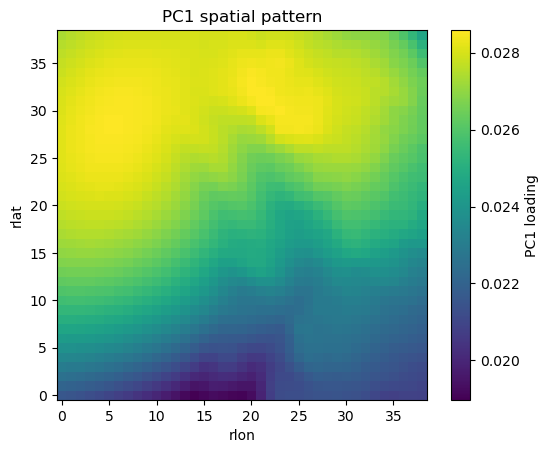

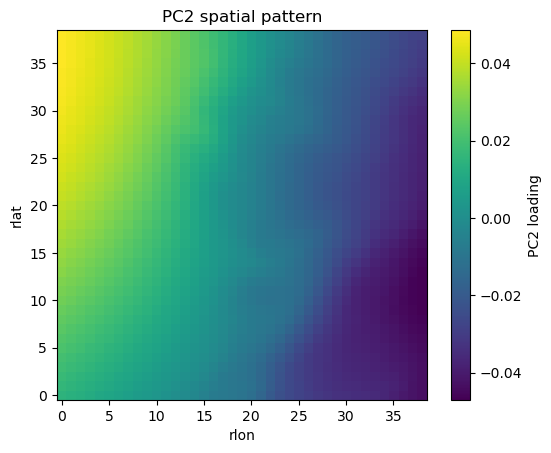

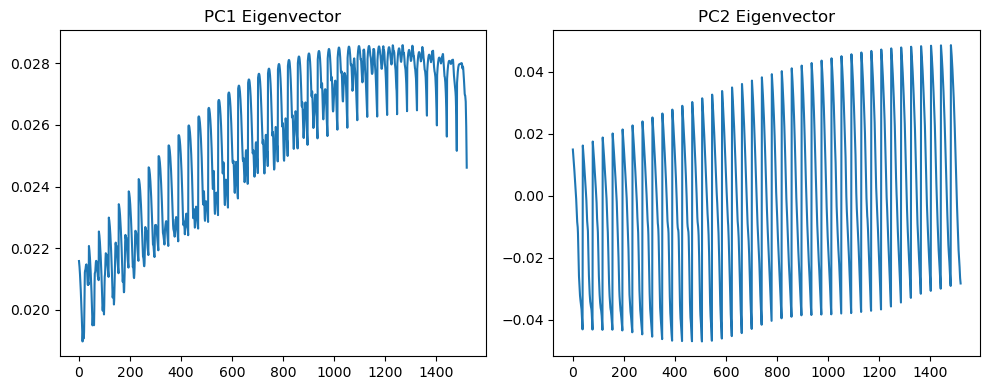

In [18]:
PC1_cut_map_pressure = pca_cut_pressure.components_[0].reshape(n_rlat, n_rlon)
plt.imshow(PC1_cut_map_pressure, origin="lower")
plt.colorbar(label="PC1 loading")
plt.title("PC1 spatial pattern")
plt.xlabel("rlon")
plt.ylabel("rlat")
plt.show()

PC2_cut_map_pressure = pca_cut_pressure.components_[1].reshape(n_rlat, n_rlon)
plt.imshow(PC2_cut_map_pressure, origin="lower")
plt.colorbar(label="PC2 loading")
plt.title("PC2 spatial pattern")
plt.xlabel("rlon")
plt.ylabel("rlat")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(pca_cut_pressure.components_[0])
axes[0].set_title("PC1 Eigenvector")
axes[1].plot(pca_cut_pressure.components_[1])
axes[1].set_title("PC2 Eigenvector")
plt.tight_layout()
plt.show()

In [19]:
for file in files:
    if "rsds" in xr.open_dataset(file).data_vars: 
        ds = xr.open_dataset(file) 
        break

ds_2007_solar = ds.sel(time=slice("2007-01-03", "2007-12-31")) #Select data from January 2007

In [20]:
print(ds_2007_solar)

<xarray.Dataset> Size: 1GB
Dimensions:       (time: 2904, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 23kB 2007-01-03 00:00:00 ... 2007-12-31 21:00:00
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB ...
    lat           (rlat, rlon) float64 922kB ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 46kB ...
    rotated_pole  |S1 1B ...
    rsds          (time, rlat, rlon) float32 1GB ...
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization:                    1
    ...                  

In [21]:
ds_2007_cut_solar = ds_2007_solar.isel(rlat=slice(i_min, i_max + 1),rlon=slice(j_min, j_max + 1))
print(ds_2007_cut_solar)

<xarray.Dataset> Size: 18MB
Dimensions:       (time: 2904, bnds: 2, rlat: 39, rlon: 39)
Coordinates:
  * time          (time) object 23kB 2007-01-03 00:00:00 ... 2007-12-31 21:00:00
  * rlat          (rlat) float64 312B 0.53 0.75 0.97 1.19 ... 8.45 8.67 8.89
  * rlon          (rlon) float64 312B -21.89 -21.67 -21.45 ... -13.75 -13.53
    lon           (rlat, rlon) float64 12kB ...
    lat           (rlat, rlon) float64 12kB ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 46kB ...
    rotated_pole  |S1 1B ...
    rsds          (time, rlat, rlon) float32 18MB ...
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization:                    1
    ...                          

In [22]:
print(ds_2007_cut)
print("GAP")
print(ds_2007_cut_solar)

<xarray.Dataset> Size: 18MB
Dimensions:       (time: 2904, bnds: 2, rlat: 39, rlon: 39)
Coordinates:
  * time          (time) object 23kB 2007-01-03 00:00:00 ... 2007-12-31 21:00:00
  * rlat          (rlat) float64 312B 0.53 0.75 0.97 1.19 ... 8.45 8.67 8.89
  * rlon          (rlon) float64 312B -21.89 -21.67 -21.45 ... -13.75 -13.53
    lon           (rlat, rlon) float64 12kB 232.0 232.3 232.5 ... 239.3 239.6
    lat           (rlat, rlon) float64 12kB 43.66 43.74 43.82 ... 54.29 54.35
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 46kB ...
    rotated_pole  |S1 1B ...
    psl           (time, rlat, rlon) float32 18MB 1.013e+05 ... 1.036e+05
Attributes: (12/19)
    CDI:                            Climate Data Interface version 2.0.3 (htt...
    Conventions:                    CF-1.4
    institution:                    CCCma (Canadian Centre for Climate Modell...
    title:                          CanRCM4 model output prepared for CORDEX ...

In [23]:
print(ds_2007_cut.time.values[0])
print(ds_2007_cut.time.values[1])
print(ds_2007_cut.time.values[2])
print(ds_2007_cut.time.values[-2])
print(ds_2007_cut.time.values[-1])
print("GAP")
print(ds_2007_cut_solar.time.values[0])
print(ds_2007_cut_solar.time.values[1])
print(ds_2007_cut_solar.time.values[2])
print(ds_2007_cut_solar.time.values[-2])
print(ds_2007_cut_solar.time.values[-1])


2007-01-03 00:00:00
2007-01-03 03:00:00
2007-01-03 06:00:00
2007-12-31 18:00:00
2007-12-31 21:00:00
GAP
2007-01-03 00:00:00
2007-01-03 03:00:00
2007-01-03 06:00:00
2007-12-31 18:00:00
2007-12-31 21:00:00


## Regression using PC Scores of both solar and pressure as predictors

So, \
ds_2007_cut is the dataset for pressure \
ds_2007_cut_solar is the dataset for solar radiation\
\
Both of these have 3-hourly data for the year 2007

In [24]:
psl_cut = ds_2007_cut["psl"]
n_time = psl_cut.sizes["time"]
n_rlat = psl_cut.sizes["rlat"]
n_rlon = psl_cut.sizes["rlon"]

X_cut_psl = psl_cut.values.reshape(n_time, n_rlat * n_rlon)
X_mean_cut_psl = X_cut_psl.mean(axis=0)
X_centered_cut_psl = X_cut_psl - X_mean_cut_psl
print(X_centered_cut_psl.shape) 
pca_cut_pressure = PCA(n_components=2)
PCs_cut_pressure = pca_cut_pressure.fit_transform(X_centered_cut_psl)

print(pca_cut_pressure.explained_variance_ratio_)
print(pca_cut_pressure.explained_variance_ratio_.sum())

(2904, 1521)
[0.8045555  0.11177385]
0.9163293


In [25]:
solar_cut = ds_2007_cut_solar["rsds"]
n_time = solar_cut.sizes["time"]
n_rlat = solar_cut.sizes["rlat"]
n_rlon = solar_cut.sizes["rlon"]

X_cut_solar = solar_cut.values.reshape(n_time, n_rlat * n_rlon)
X_mean_cut_solar = X_cut_solar.mean(axis=0)
X_centered_cut_solar = X_cut_solar - X_mean_cut_solar
print(X_centered_cut_solar.shape) 
pca_cut_solar = PCA(n_components=2)
PCs_cut_solar = pca_cut_solar.fit_transform(X_centered_cut_solar)

print(pca_cut_solar.explained_variance_ratio_)
print(pca_cut_solar.explained_variance_ratio_.sum())

(2904, 1521)
[0.857144   0.03093701]
0.888081


In [26]:
ds_hr_solar= xr.open_dataset("/home/dtaneja/analysis-dishika/notebooks/HRDPS_2007_solar.nc")
solar = ds_hr_solar["solar"]
X_hr_solar = solar.values.reshape(2904, 266 * 256)
pca_hr_solar = PCA(n_components=2)
PCs_hr_solar = pca_hr_solar.fit_transform(X_hr_solar)
PCs_hr_solar.shape

print("Eigenvectors (Principal Components):")
print(pca_hr_solar.components_)
print("PC scores:")
print(PCs_hr_solar)
print("Explained Variance Ratio:")
print(pca_hr_solar.explained_variance_ratio_)
print("Total Variance Explained by the 2 Principal Components:")
print(pca_hr_solar.explained_variance_ratio_.sum())

Eigenvectors (Principal Components):
[[ 0.0040077   0.00400669  0.0040127  ...  0.00362554  0.00364674
   0.00364445]
 [ 0.0032755   0.003267    0.00327573 ... -0.00327957 -0.00335937
  -0.00342429]]
PC scores:
[[-38055.89       1323.702   ]
 [-40581.75         70.68115 ]
 [-40581.75         70.706215]
 ...
 [-39081.41       -128.1466  ]
 [  6269.491       643.1451  ]
 [ 16939.77      -3665.5762  ]]
Explained Variance Ratio:
[0.9017883  0.02422546]
Total Variance Explained by the 2 Principal Components:
0.92601377


In [27]:
time = pd.to_datetime([str(t) for t in ds_2007_cut.time.values])

pc_df = pd.DataFrame({
    "time": time,
    "LR_pressure_PC1": PCs_cut_pressure[:, 0],
    "LR_pressure_PC2": PCs_cut_pressure[:, 1],
    "LR_solar_PC1": PCs_cut_solar[:, 0],
    "LR_solar_PC2": PCs_cut_solar[:, 1],
    "HR_solar_PC1": PCs_hr_solar[:, 0],
    "HR_solar_PC2": PCs_hr_solar[:, 1],
})

print(pc_df.head())
print(pc_df.shape)

                 time  LR_pressure_PC1  LR_pressure_PC2  LR_solar_PC1  \
0 2007-01-03 00:00:00    -65762.281250      4791.501465  -2991.300537   
1 2007-01-03 03:00:00    -60669.042969      5523.444336  -5450.812500   
2 2007-01-03 06:00:00    -57886.335938      4231.009277  -5568.754395   
3 2007-01-03 09:00:00    -56332.640625      1797.595459  -5568.754395   
4 2007-01-03 12:00:00    -54928.476562      -434.885406  -5568.754395   

   LR_solar_PC2  HR_solar_PC1  HR_solar_PC2  
0    711.214050 -38055.890625   1323.702026  
1    143.203506 -40581.750000     70.681152  
2     23.997456 -40581.750000     70.706215  
3     23.997406 -40581.750000     70.706169  
4     23.997412 -40581.750000     70.706169  
(2904, 7)


In [28]:
train_df = pc_df[pc_df["time"].dt.month <= 9]
test_df = pc_df[pc_df["time"].dt.month >= 10]
print("Training dates:")
print(train_df["time"].min())
print(train_df["time"].max())
print("Testing dates:")
print(test_df["time"].min())
print(test_df["time"].max())

Training dates:
2007-01-03 00:00:00
2007-09-30 21:00:00
Testing dates:
2007-10-01 00:00:00
2007-12-31 21:00:00


In [29]:
X_train = train_df[["LR_pressure_PC1","LR_pressure_PC2","LR_solar_PC1","LR_solar_PC2"]]
X_test = test_df[["LR_pressure_PC1","LR_pressure_PC2","LR_solar_PC1","LR_solar_PC2"]]
y_train = train_df[["HR_solar_PC1","HR_solar_PC2"]]
y_test = test_df[["HR_solar_PC1","HR_solar_PC2"]]

In [30]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
list(mlr.coef_)

[array([  0.07268588,   0.34216154,   5.818627  , -10.428581  ],
       dtype=float32),
 array([0.00835545, 0.07644549, 0.17310067, 3.811683  ], dtype=float32)]

In [32]:
print(mlr.intercept_)

[1014.0464 -259.2425]


In [33]:
y_pred = mlr.predict(X_test)


In [34]:
print(y_test)

      HR_solar_PC1  HR_solar_PC2
2168 -23922.308594   9985.268555
2169 -40564.531250     99.763176
2170 -40581.750000     70.706169
2171 -40581.750000     70.706169
2172 -40581.750000     70.706169
...            ...           ...
2899 -40581.750000     70.706169
2900 -40581.750000     70.706169
2901 -39081.410156   -128.146606
2902   6269.491211    643.145081
2903  16939.769531  -3665.576172

[736 rows x 2 columns]


In [35]:
print(y_pred)

[[-41307.773   20762.03  ]
 [-40450.82     6010.2803]
 [-33225.855   -1197.5516]
 ...
 [-30018.5     -1279.3379]
 [-22501.252   -2610.1511]
 [ 22112.842   -4941.114 ]]


In [36]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
adj_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - 4 - 1)
avg_metrics_df = pd.DataFrame({
    "Metric": ["Average MSE", "Average MAE", "Average R2", "Average Adjusted R2"],
    "Value": [mse, mae, r2, adj_r2]
})
 
avg_metrics_df

,Metric,Value
0,Average MSE,2.120688e+08
1,Average MAE,8.454686e+03
2,Average R2,3.024939e-01
3,Average Adjusted R2,2.986772e-01


In [37]:
mse_each = mean_squared_error(y_test, y_pred, multioutput="raw_values")
mae_each = mean_absolute_error(y_test, y_pred, multioutput="raw_values")
n = len(y_test)
p = X_test.shape[1]  
r2_each = r2_score(y_test, y_pred, multioutput="raw_values")
adj_r2_each = 1 - (1 - r2_each) * (n - 1) / (n - p - 1)
metrics_df = pd.DataFrame({
    "R2": r2_each,
    "Adjusted_R2": adj_r2_each,
    "MSE": mse_each,
    "MAE": mae_each
}, index=y_test.columns)

metrics_df

,R2,Adjusted_R2,MSE,MAE
HR_solar_PC1,0.394361,0.391047,406633568.0,14048.62793
HR_solar_PC2,0.210627,0.206308,17504040.0,2860.74292


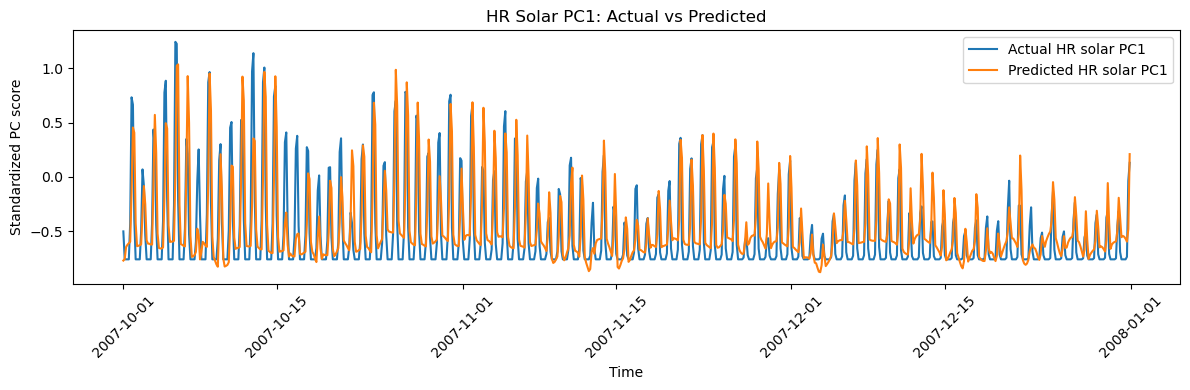

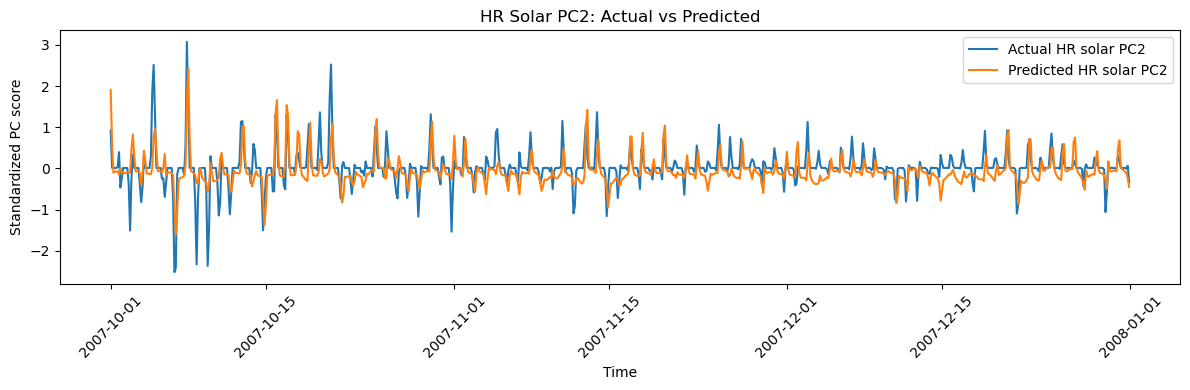

In [38]:
pred_df = test_df[["time", "HR_solar_PC1", "HR_solar_PC2"]].copy()
pred_df["HR_solar_PC1_pred"] = y_pred[:, 0]
pred_df["HR_solar_PC2_pred"] = y_pred[:, 1]

pc1_mean = y_train["HR_solar_PC1"].mean()
pc1_std = y_train["HR_solar_PC1"].std()
pc2_mean = y_train["HR_solar_PC2"].mean()
pc2_std = y_train["HR_solar_PC2"].std()

pred_df["HR_solar_PC1_std"] = (pred_df["HR_solar_PC1"] - pc1_mean) / pc1_std
pred_df["HR_solar_PC1_pred_std"] = (pred_df["HR_solar_PC1_pred"] - pc1_mean) / pc1_std
pred_df["HR_solar_PC2_std"] = (pred_df["HR_solar_PC2"] - pc2_mean) / pc2_std
pred_df["HR_solar_PC2_pred_std"] = (pred_df["HR_solar_PC2_pred"] - pc2_mean) / pc2_std

plt.figure(figsize=(12, 4))
plt.plot(pred_df["time"],pred_df["HR_solar_PC1_std"],label="Actual HR solar PC1")
plt.plot(pred_df["time"],pred_df["HR_solar_PC1_pred_std"],label="Predicted HR solar PC1")
plt.title("HR Solar PC1: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Standardized PC score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(pred_df["time"],pred_df["HR_solar_PC2_std"],label="Actual HR solar PC2")
plt.plot(pred_df["time"],pred_df["HR_solar_PC2_pred_std"],label="Predicted HR solar PC2")
plt.title("HR Solar PC2: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Standardized PC score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Regression for predicting HRDPS pressure from PCs of CanRCM5

In [43]:
lr_scores_pressure = PCs_cut_pressure[:, :2]
hr_scores_pressure = PCs_hr_pressure[:, :2]

time = pd.to_datetime([str(t) for t in ds_2007_cut.time.values])

pc_pressure_df = pd.DataFrame({
    "time": time,
    "CanRCM_pressure_PC1": lr_scores_pressure[:, 0],
    "CanRCM_pressure_PC2": lr_scores_pressure[:, 1],
    "HRDPS_pressure_PC1": hr_scores_pressure[:, 0],
    "HRDPS_pressure_PC2": hr_scores_pressure[:, 1]
})

pc_pressure_df.head()

,time,CanRCM_pressure_PC1,CanRCM_pressure_PC2,HRDPS_pressure_PC1,HRDPS_pressure_PC2
0,2007-01-03 00:00:00,-65762.281250,4791.501465,-399449.18750,-37408.578125
1,2007-01-03 03:00:00,-60669.042969,5523.444336,-364888.15625,-27151.966797
2,2007-01-03 06:00:00,-57886.335938,4231.009277,-341864.90625,-19617.996094
3,2007-01-03 09:00:00,-56332.640625,1797.595459,-319362.81250,-7399.109375
4,2007-01-03 12:00:00,-54928.476562,-434.885406,-344046.25000,20654.542969


In [ ]:
train_df = pc_pressure_df[pc_pressure_df["time"] < "2007-10-01"]
test_df = pc_pressure_df[pc_pressure_df["time"] >= "2007-10-01"]


In [46]:
train_df["time"].min(), train_df["time"].max()

(Timestamp('2007-01-03 00:00:00'), Timestamp('2007-09-30 21:00:00'))

In [47]:
test_df["time"].min(), test_df["time"].max()

(Timestamp('2007-10-01 00:00:00'), Timestamp('2007-12-31 21:00:00'))

In [48]:
X_train = train_df[["CanRCM_pressure_PC1", "CanRCM_pressure_PC2"]]
y_train = train_df[["HRDPS_pressure_PC1", "HRDPS_pressure_PC2"]]

X_test = test_df[["CanRCM_pressure_PC1", "CanRCM_pressure_PC2"]]
y_test = test_df[["HRDPS_pressure_PC1", "HRDPS_pressure_PC2"]]

In [49]:
pressure_model = LinearRegression()
pressure_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [51]:
pressure_model.coef_

array([[ 7.1065416 , -0.7946758 ],
       [-0.06467598, -4.623133  ]], dtype=float32)

In [52]:
pressure_model.intercept_

array([ 2148.609 , -1690.0977], dtype=float32)

In [53]:
y_pred = pressure_model.predict(X_test)

In [54]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
adj_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - 2 - 1)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)
print("Adjusted R-squared:", adj_r2)

Mean Squared Error: 1856639360.0
Mean Absolute Error: 29798.54296875
R-squared: 0.8561495542526245
Adjusted R-squared: 0.8557570564470383


In [58]:
n = len(y_test)
p = X_test.shape[1]
mse_each = mean_squared_error(y_test, y_pred, multioutput="raw_values")
mae_each = mean_absolute_error(y_test, y_pred, multioutput="raw_values")
r2_each = r2_score(y_test, y_pred, multioutput="raw_values")
adj_r2_each = 1 - (1 - r2_each) * (n - 1) / (n - p - 1)

pressure_metrics_df = pd.DataFrame({
    "Target PC": ["HRDPS_pressure_PC1", "HRDPS_pressure_PC2"],
    "MSE": mse_each,
    "MAE": mae_each,
    "R2": r2_each,
    "Adjusted R2": adj_r2_each
})

pressure_metrics_df

,Target PC,MSE,MAE,R2,Adjusted R2
0,HRDPS_pressure_PC1,2.977838e+09,38419.371094,0.963738,0.963639
1,HRDPS_pressure_PC2,7.354411e+08,21177.716797,0.748562,0.747875


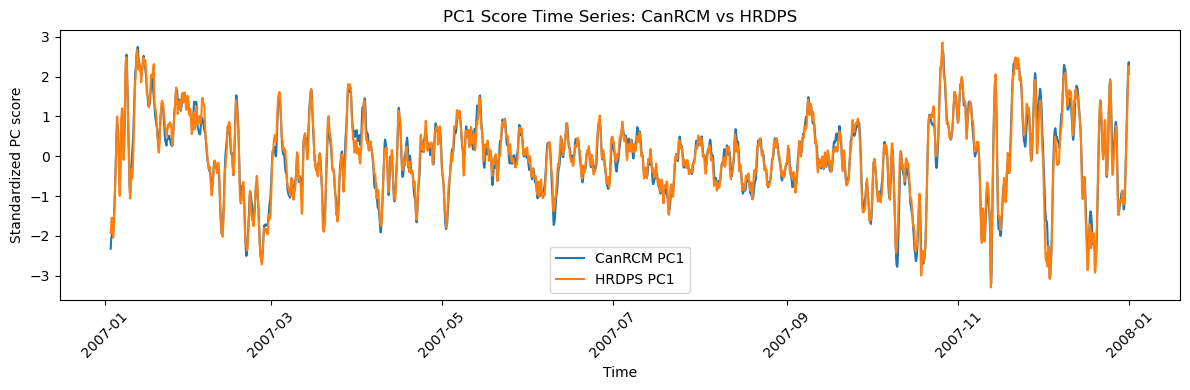

In [56]:
pc_pressure_df["CanRCM_PC1_std"] = (pc_pressure_df["CanRCM_pressure_PC1"] - pc_pressure_df["CanRCM_pressure_PC1"].mean()) / pc_pressure_df["CanRCM_pressure_PC1"].std()
pc_pressure_df["HRDPS_PC1_std"] = (pc_pressure_df["HRDPS_pressure_PC1"] - pc_pressure_df["HRDPS_pressure_PC1"].mean()) / pc_pressure_df["HRDPS_pressure_PC1"].std()

plt.figure(figsize=(12, 4))
plt.plot(pc_pressure_df["time"], pc_pressure_df["CanRCM_PC1_std"], label="CanRCM PC1")
plt.plot(pc_pressure_df["time"], pc_pressure_df["HRDPS_PC1_std"], label="HRDPS PC1")
plt.title("PC1 Score Time Series: CanRCM vs HRDPS")
plt.xlabel("Time")
plt.ylabel("Standardized PC score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

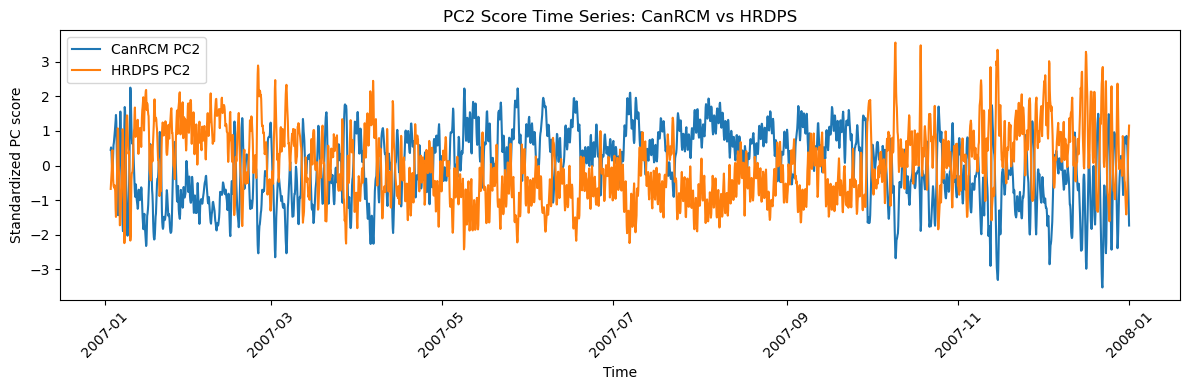

In [57]:
pc_pressure_df["CanRCM_PC2_std"] = (pc_pressure_df["CanRCM_pressure_PC2"] - pc_pressure_df["CanRCM_pressure_PC2"].mean()) / pc_pressure_df["CanRCM_pressure_PC2"].std()
pc_pressure_df["HRDPS_PC2_std"] = (pc_pressure_df["HRDPS_pressure_PC2"] - pc_pressure_df["HRDPS_pressure_PC2"].mean()) / pc_pressure_df["HRDPS_pressure_PC2"].std()

plt.figure(figsize=(12, 4))
plt.plot(pc_pressure_df["time"], pc_pressure_df["CanRCM_PC2_std"], label="CanRCM PC2")
plt.plot(pc_pressure_df["time"], pc_pressure_df["HRDPS_PC2_std"], label="HRDPS PC2")
plt.title("PC2 Score Time Series: CanRCM vs HRDPS")
plt.xlabel("Time")
plt.ylabel("Standardized PC score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()